# Exp3 Deep-Dive — training internals (per arm)

Per-arm training-time internals (candidate reward distribution; GRPO advantage signal; PTO margins).
Latent-space preference analysis lives in `03_Preference_Analysis.ipynb`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("."))           # cwd = eda/ -> `import exp3`
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.width", 185, "display.max_columns", 50)
import exp3
from exp3 import stats, behavior, training, figures
figures.set_style()
ARMS   = exp3.discover_arms()
SCORES = exp3.load_scores_long(ARMS)
PALETTE = figures.arm_palette(sorted(SCORES.arm.unique()))
METRICS = [m for m in exp3.QUESTIONNAIRE_ORDER if m in SCORES.questionnaire.unique()]
ORACLE_NOISE = 0.10   # oracle reproducibility band (~0.07-0.10 |Δ|, partial-conv EDA): min meaningful diff
print("arms on disk:", [(a.label, len(a.iters)) for a in ARMS])
print("scores_long:", SCORES.shape, "| arms scored:", sorted(SCORES.arm.unique()))
print("exports ->", exp3.RESULTS_DIR)

arms on disk: [('PTO_LA0', 11), ('PTO_LA5', 2), ('GRPO_LA0', 4), ('GRPO_LA5', 2)]
scores_long: (12096, 19) | arms scored: ['GRPO_LA0', 'GRPO_LA5', 'PTO_LA0', 'PTO_LA5']
exports -> c:\Users\baruc\Desktop\Projects\Thesis_PTO_GRPO\Exp3_PTO_GRPO\eda\results


In [2]:
RUN = "PTO_LA0"
ARM = [a for a in ARMS if a.label == RUN][0]; GENS = training.load_generations([ARM])
print("arm:", ARM.label, "| method:", ARM.method, "| K:", ARM.K, "| iters:", ARM.iters, "| candidates:", len(GENS))

arm: PTO_LA0 | method: PTO | K: 0 | iters: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10] | candidates: 49920


## 1 · Candidate reward distribution per training iteration

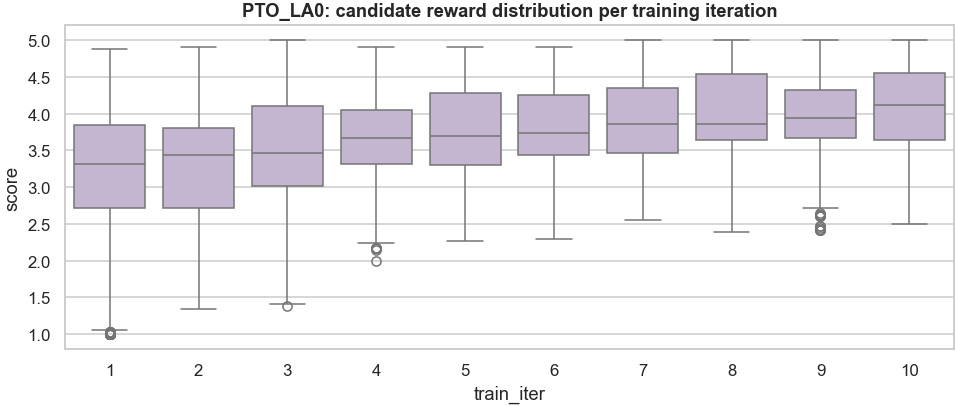

In [3]:
fig, ax = plt.subplots(figsize=(9,4)); sns.boxplot(GENS, x="train_iter", y="score", color="#c5b0d5", ax=ax)
ax.set_title(f"{RUN}: candidate reward distribution per training iteration"); fig.tight_layout()
exp3.save_fig(fig, f"{RUN}_train_reward_dist", caption=f"{RUN}: distribution of per-candidate training reward per iteration."); plt.show()

## 2 · Method-specific advantage signal

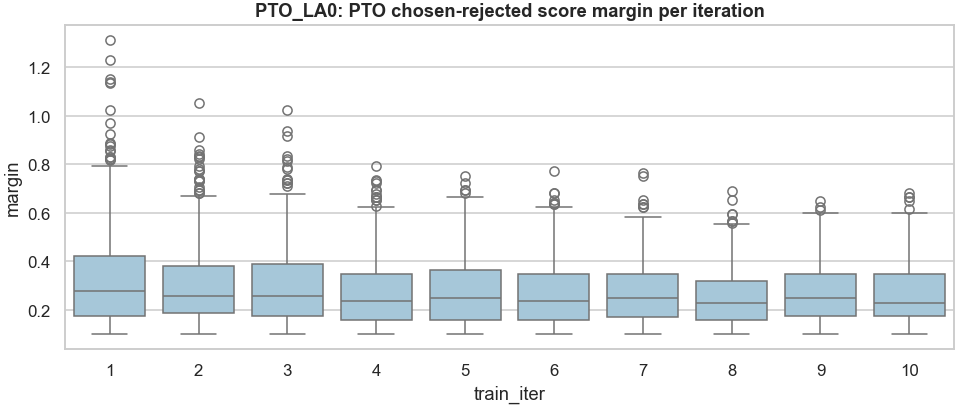

,count,mean,median
train_iter,,,
1,782,0.322,0.276
2,618,0.299,0.259
3,620,0.295,0.259
4,536,0.269,0.235
5,483,0.281,0.247
6,475,0.267,0.235
7,400,0.272,0.247
8,379,0.249,0.229
9,361,0.266,0.247


In [4]:
if ARM.method == "GRPO":
    grp = GENS.groupby("train_iter").agg(group_std=("group_std","mean"), frac_zero_std=("group_std", lambda s:(s.fillna(0)<1e-6).mean())).reset_index()
    print("GRPO group-std + frac near-zero per iter:"); display(grp.round(4))
else:
    pp = training.load_pref_pairs([ARM])
    if len(pp):
        pp["margin"] = pp["chosen_score"] - pp["rejected_score"]
        fig, ax = plt.subplots(figsize=(9,4)); sns.boxplot(pp, x="train_iter", y="margin", color="#9ecae1", ax=ax)
        ax.set_title(f"{RUN}: PTO chosen-rejected score margin per iteration"); fig.tight_layout()
        exp3.save_fig(fig, f"{RUN}_pref_margin", caption=f"{RUN}: PTO chosen-rejected oracle-score margin per iteration."); plt.show()
        display(pp.groupby("train_iter")["margin"].agg(["count","mean","median"]).round(3))

## 3 · Takeaways
- _(is the training signal healthy across iterations?)_